# Qwen-VL RL 数据查看 Notebook

这个 notebook 用来直观查看当前已经转换好的两份 RL 数据：

- `wo_thinking_thyme_single_round-00000-of-00146.qwen_vl_ppo.jsonl`
- `wo_thinking_thyme_single_round-00000-of-00146.qwen_vl_grpo.jsonl`

重点查看：

- 样本字段结构
- `messages` / `prompt` 的多模态格式
- `ground_truth` / `reward_target` 等训练相关字段
- 样本中的图像可视化效果


In [2]:
import base64
import io
import json
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Markdown, display

PROJECT_DIR = Path('/root/rivermind-data/NJU_RL_examine')
PPO_PATH = PROJECT_DIR / 'wo_thinking_thyme_single_round-00000-of-00146.qwen_vl_ppo.jsonl'
GRPO_PATH = PROJECT_DIR / 'wo_thinking_thyme_single_round-00000-of-00146.qwen_vl_grpo.jsonl'

print('PPO 文件:', PPO_PATH)
print('GRPO 文件:', GRPO_PATH)
print('PPO 存在:', PPO_PATH.exists())
print('GRPO 存在:', GRPO_PATH.exists())


PPO 文件: /root/rivermind-data/NJU_RL_examine/wo_thinking_thyme_single_round-00000-of-00146.qwen_vl_ppo.jsonl
GRPO 文件: /root/rivermind-data/NJU_RL_examine/wo_thinking_thyme_single_round-00000-of-00146.qwen_vl_grpo.jsonl
PPO 存在: True
GRPO 存在: True


In [3]:
def count_jsonl(path: Path) -> int:
    with path.open('r', encoding='utf-8') as f:
        return sum(1 for _ in f)


def load_sample(path: Path, index: int) -> dict:
    with path.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i == index:
                return json.loads(line)
    raise IndexError(f'{path.name} 中不存在第 {index} 条样本')


def pretty_json(obj, max_chars: int = 1200) -> str:
    text = json.dumps(obj, ensure_ascii=False, indent=2)
    if len(text) > max_chars:
        return text[:max_chars] + '\n...\n[内容过长，已截断]'
    return text


def extract_content_list(sample: dict):
    if 'messages' in sample:
        return sample['messages'][0]['content']
    if 'prompt' in sample:
        return sample['prompt'][0]['content']
    return []


def extract_first_image(sample: dict):
    for item in extract_content_list(sample):
        if item.get('type') == 'image':
            return item.get('image')
    return None


def extract_text_prompt(sample: dict) -> str:
    texts = []
    for item in extract_content_list(sample):
        if item.get('type') == 'text':
            texts.append(item.get('text', ''))
    return '\n'.join(texts).strip()


def decode_image(image_value: str) -> Image.Image:
    if image_value.startswith('data:image'):
        image_value = image_value.split(',', 1)[1]
    image_bytes = base64.b64decode(image_value)
    return Image.open(io.BytesIO(image_bytes)).convert('RGB')


def show_image_from_sample(sample: dict, figsize=(8, 6)):
    image_value = extract_first_image(sample)
    if image_value is None:
        print('该样本没有图像内容')
        return
    image = decode_image(image_value)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis('off')
    plt.show()


def show_sample(sample: dict, title: str):
    display(Markdown(f'## {title}'))
    print('字段列表:')
    print(sorted(sample.keys()))
    print()
    print('question:')
    print(sample.get('question', ''))
    print('\n' + '=' * 80)
    print('ground_truth:')
    print(sample.get('ground_truth'))
    print('\n' + '=' * 80)
    if 'reference_answer' in sample:
        print('reference_answer:')
        print(sample.get('reference_answer'))
        print('\n' + '=' * 80)
    if 'reward_target' in sample:
        print('reward_target:')
        print(sample.get('reward_target'))
        print('\n' + '=' * 80)
    print('choice_letter:', sample.get('choice_letter'))
    print('answer_normalized:', sample.get('answer_normalized'))
    print('task_type:', sample.get('task_type'))
    print('image_count:', sample.get('image_count'))
    print('num_source_images:', sample.get('num_source_images'))
    print('\n' + '=' * 80)
    print('多模态 content 类型:')
    print([item.get('type') for item in extract_content_list(sample)])
    print('\n' + '=' * 80)
    print('抽取出的文本 prompt:')
    print(extract_text_prompt(sample))
    print('\n' + '=' * 80)
    print('metadata:')
    print(pretty_json(sample.get('metadata', {}), max_chars=2000))


In [4]:
ppo_count = count_jsonl(PPO_PATH)
grpo_count = count_jsonl(GRPO_PATH)

print('PPO 样本数:', ppo_count)
print('GRPO 样本数:', grpo_count)

ppo_sample_0 = load_sample(PPO_PATH, 0)
grpo_sample_0 = load_sample(GRPO_PATH, 0)

print('\nPPO 第 0 条字段:')
print(sorted(ppo_sample_0.keys()))

print('\nGRPO 第 0 条字段:')
print(sorted(grpo_sample_0.keys()))


PPO 样本数: 1242
GRPO 样本数: 1242

PPO 第 0 条字段:
['answer_normalized', 'choice_letter', 'ground_truth', 'id', 'image_count', 'messages', 'metadata', 'num_source_images', 'question', 'reference_answer', 'source_file', 'task_type']

GRPO 第 0 条字段:
['answer_normalized', 'choice_letter', 'ground_truth', 'id', 'image_count', 'metadata', 'num_source_images', 'prompt', 'question', 'reward_target', 'reward_type', 'source_file', 'task_type']


## PPO 文件内容示例

下面展示 `qwen_vl_ppo.jsonl` 中的样本示例，并可视化其中的图像。

## PPO 样本 0

字段列表:
['answer_normalized', 'choice_letter', 'ground_truth', 'id', 'image_count', 'messages', 'metadata', 'num_source_images', 'question', 'reference_answer', 'source_file', 'task_type']

question:
Based on panel a, which statement best describes the effect of directionality on the real part of the second eigenvalue (Re λ2) at high edge densities? The choices are listed below:
A. Directionality has no effect on the real part of the second eigenvalue.
B. Directed networks show a higher real part of the second eigenvalue than undirected networks.
C. Undirected networks show a higher real part of the second eigenvalue than directed networks.
D. Directed networks show a more pronounced decrease in the real part of the second eigenvalue than undirected networks.

ground_truth:
B

reference_answer:
B

choice_letter: B
answer_normalized: B
task_type: visual_multiple_choice_qa
image_count: 1
num_source_images: 2

多模态 content 类型:
['image', 'text']

抽取出的文本 prompt:
Based on panel a, which stateme

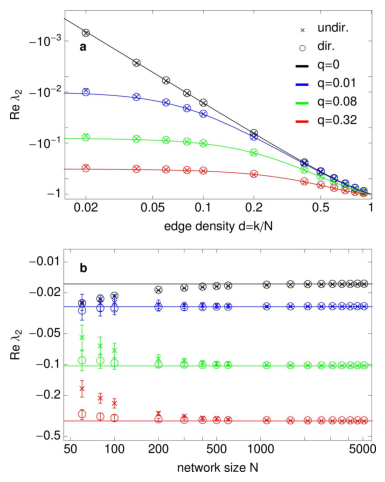

In [5]:
ppo_sample_0 = load_sample(PPO_PATH, 0)
show_sample(ppo_sample_0, 'PPO 样本 0')
show_image_from_sample(ppo_sample_0)


In [ ]:
ppo_sample_10 = load_sample(PPO_PATH, 10)
show_sample(ppo_sample_10, 'PPO 样本 10')
show_image_from_sample(ppo_sample_10)


## GRPO 文件内容示例

下面展示 `qwen_vl_grpo.jsonl` 中的样本示例，并可视化其中的图像。

In [ ]:
grpo_sample_0 = load_sample(GRPO_PATH, 0)
show_sample(grpo_sample_0, 'GRPO 样本 0')
show_image_from_sample(grpo_sample_0)


In [ ]:
grpo_sample_10 = load_sample(GRPO_PATH, 10)
show_sample(grpo_sample_10, 'GRPO 样本 10')
show_image_from_sample(grpo_sample_10)


## PPO / GRPO 同一条样本对照

这个单元格可以对照同一个 `id` 在两种 RL 文件中的表示差异。

In [ ]:
index = 0
ppo_sample = load_sample(PPO_PATH, index)
grpo_sample = load_sample(GRPO_PATH, index)

display(Markdown(f'## 同一 index 对照: {index}'))
print('PPO keys:')
print(sorted(ppo_sample.keys()))
print('\nGRPO keys:')
print(sorted(grpo_sample.keys()))
print('\n' + '=' * 80)
print('PPO reference_answer:', ppo_sample.get('reference_answer'))
print('GRPO reward_target:', grpo_sample.get('reward_target'))
print('PPO content 类型:', [x['type'] for x in ppo_sample['messages'][0]['content']])
print('GRPO content 类型:', [x['type'] for x in grpo_sample['prompt'][0]['content']])
print('\n两边 question 是否一致:', ppo_sample.get('question') == grpo_sample.get('question'))
print('两边 ground_truth 是否一致:', ppo_sample.get('ground_truth') == grpo_sample.get('ground_truth'))
